In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import re
from scipy import signal
from pathlib import Path
import logging
import sys
import importlib
import utils.data_loader
importlib.reload(utils.data_loader)
from utils.data_loader import load_hdf5_strain
sys.path.append("../src/python")
from utils.data_loader import load_hdf5_strain

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(message)s",
    stream=sys.stdout,
    force=True
)

DATA_DIR = Path("../data/raw")

files = list(DATA_DIR.glob("*.hdf5"))
print(files[0])
print(files[1])

../data/raw/H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5
../data/raw/L-L1_GWOSC_4KHZ_R1-1264316101-32.hdf5


In [84]:
strain_h = load_hdf5_strain(files[0])
strain_l = load_hdf5_strain(files[1])

2026-05-05 20:34:06,626 - INFO - Dataset shape: (131072,)  (~1.00 MB)
2026-05-05 20:34:06,648 - INFO - Dataset shape: (131072,)  (~1.00 MB)


In [85]:
# Sampling rate
fs = 4096
# Time
t = np.arange(len(strain_h)) / fs
print(t)
print(len(t))

[0.00000000e+00 2.44140625e-04 4.88281250e-04 ... 3.19992676e+01
 3.19995117e+01 3.19997559e+01]
131072


In [122]:
# STD tells you whether your signal is visible or buried in noise
# Compute Hanford
# Less Noisier because of the lower STD
logger.info(f"Strain Hanford Mean: {np.mean(strain_h)}")
logger.info(f"Strain Hanford STD: {np.std(strain_h)}")
logger.info(f"Strain Hanford Variance: {np.var(strain_h)}")
print("-------------------------------------------------------------------------------------\n")
# Compute Livingstone
# Much noisier because of the higher STD
logger.info(f"Strain Livingstone Mean: {np.mean(strain_l)}")
logger.info(f"Strain Livingstone STD: {np.std(strain_l)}")
logger.info(f"Strain Livingstone Variance: {np.var(strain_l)}")
print("-------------------------------------------------------------------------------------\n")

2026-05-05 21:28:58,821 - INFO - Strain Hanford Mean: -8.129713531576374e-24
2026-05-05 21:28:58,825 - INFO - Strain Hanford STD: 4.6610974429647713e-20
2026-05-05 21:28:58,829 - INFO - Strain Hanford Variance: 2.172582937281273e-39
-------------------------------------------------------------------------------------

2026-05-05 21:28:58,831 - INFO - Strain Livingstone Mean: -1.5034709494044763e-21
2026-05-05 21:28:58,833 - INFO - Strain Livingstone STD: 7.950327690745316e-19
2026-05-05 21:28:58,835 - INFO - Strain Livingstone Variance: 6.320771039023175e-37
-------------------------------------------------------------------------------------



In [134]:
window_size = 256 # 256/4096 = 0.0625 seconds
windows = [
    strain_h[i:i+window_size]
    for i in range(0, len(strain_h), window_size)
    #only keep full windows of 256 points.
    #Because the last piece might be shorter.
    if len(strain_h[i:i+window_size]) == window_size
]
# 512 (len(windows)) * 0.0625
# len(windows) = total_samples (len(strain)) / window_size

In [138]:
stds = [np.std(w) for w in windows]
# Find the value where 20% of windows have std smaller than this
# windows with the lowest 20% std
threshold = np.percentile(stds, 20)

In [139]:
quiet_windows = [w for w, s in zip(windows, stds) if s <= threshold]

103

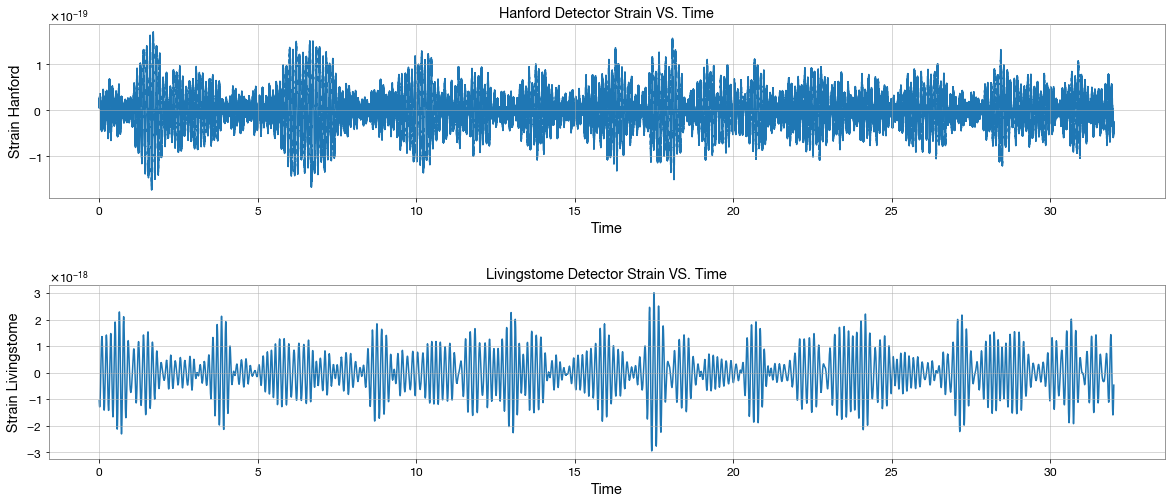

In [121]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 8))

# Hanford Strain VS Time
axes[0].plot(t, strain_h)
axes[0].set_title("Hanford Detector Strain VS. Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Strain Hanford")

# Livingstone Strain VS Time
axes[1].plot(t, strain_l)
axes[1].set_title("Livingstome Detector Strain VS. Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Strain Livingstone")

fig.subplots_adjust(left=None,
    bottom=None,
    right=None,
    top=None,
    wspace=0.1,
    hspace=0.5,)

In [21]:
start_sec = 0
duration = 2

start_idx = int(start_sec * fs)
end_idx = int(((start_sec + duration) * fs ))

print("Start Index:", start_idx, "END Index:", end_idx, "Number of Samples:", end_idx - start_idx)

Start Index: 0 END Index: 8192 Number of Samples: 8192
